# XGBoost modelling of MXene electrode capacitance

This notebook reproduces the complete workflow for the H₂SO₄ MXene corpus:

1. Load the raw CSV.
2. Inspect the schema and target coverage.
3. Parse approximate, range, and uncertainty-formatted values.
4. Normalize descriptor and capacitance units.
5. Engineer compact electrode, electrolyte, and synthesis features.
6. Train separate XGBoost regressors for gravimetric, volumetric, and areal capacitance.
7. Evaluate with **paper-grouped cross-validation** so rows from one paper cannot appear in both training and validation sets.
8. Fit final models and save models, out-of-fold predictions, metrics, and normalized data.

> **Important:** The three capacitance targets are not mixed because they use different physical bases and units. The results are exploratory because the labeled subsets are small and many descriptors are missing.

## 1. Setup

Required packages:

```bash
pip install pandas numpy scipy scikit-learn xgboost joblib matplotlib
```

The extractor notebook writes its corpus to a per-model folder — `sol/h2so4_corpus_passed.csv` for `gpt-5.6-sol`, `terra/...` for `gpt-5.6-terra`. Set `CORPUS_MODEL` below to pick which extraction run to train on. The bare repo root and `/mnt/data/` are kept as fallbacks for older layouts and hosted environments.

In [1]:
!pip install -q pandas numpy scipy scikit-learn xgboost joblib matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from __future__ import annotations

import json
import re
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
N_FOLDS = 5
OUTPUT_DIR = Path("xgb_notebook_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_UNITS = {
    "gravimetric_capacitance_F_g": "F/g",
    "volumetric_capacitance_F_cm3": "F/cm³",
    "areal_capacitance_mF_cm2": "mF/cm²",
}

## 2. Load the raw CSV

In [3]:
CORPUS_MODEL = "sol"   # <-- which extractor run to train on ("sol", "terra", ...)

candidate_paths = [
    Path(CORPUS_MODEL) / "h2so4_corpus_passed.csv",
    Path("h2so4_corpus_passed.csv"),            # legacy pre-per-model layout
    Path("/mnt/data/h2so4_corpus_passed.csv"),
]

CSV_PATH = next((path for path in candidate_paths if path.exists()), None)
if CSV_PATH is None:
    raise FileNotFoundError(
        f"Could not find h2so4_corpus_passed.csv for model '{CORPUS_MODEL}'. "
        f"Run the extractor notebook with that MODEL, or update CORPUS_MODEL / "
        f"candidate_paths. Looked in: {[str(p) for p in candidate_paths]}"
    )

raw_df = pd.read_csv(CSV_PATH)
print(f"Loaded: {CSV_PATH.resolve()}")
print(f"Shape: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns")
display(raw_df.head(3))

Loaded: C:\Users\Tomal\Desktop\mxene-geometry\h2so4_corpus_passed.csv
Shape: 122 rows × 70 columns


,source_file,source_path,doi,year,authors,electrode_label,role,is_primary,mxene_formula,mxene_formula__unit,mxene_formula__conf,composition,composition__unit,composition__conf,synthesis_method,synthesis_method__unit,synthesis_method__conf,layer_no,layer_no__unit,layer_no__conf,interlayer_spacing,interlayer_spacing__unit,interlayer_spacing__conf,flake_size,flake_size__unit,flake_size__conf,porosity,porosity__unit,porosity__conf,pore_diameter,pore_diameter__unit,pore_diameter__conf,tortuosity,tortuosity__unit,tortuosity__conf,electrode_thickness,electrode_thickness__unit,electrode_thickness__conf,mass_loading,mass_loading__unit,mass_loading__conf,electrolyte,electrolyte__unit,electrolyte__conf,ssa,ssa__unit,ssa__conf,scan_rate,scan_rate__unit,scan_rate__conf,current_density,current_density__unit,current_density__conf,gravimetric_capacitance,gravimetric_capacitance__unit,gravimetric_capacitance__conf,volumetric_capacitance,volumetric_capacitance__unit,volumetric_capacitance__conf,areal_capacitance,areal_capacitance__unit,areal_capacitance__conf,formula_match,formula_reasoning,synthesis_match,synthesis_reasoning,electrolyte_match,electrolyte_reasoning,overall,overall_reasoning
0,1-s2.0-S2369969821000785-main.pdf,1-s2.0-S2369969821000785-main.pdf,10.1016/j.jobab.2021.10.001,2022.0,Lansheng Wei et al.,CPCM/MXene,primary,True,Ti3C2Tx,NaN,stated,chitosan-based porous carbon microsphere/Ti3C2...,NaN,stated,LiF/HCl etching and ultrasonication; electrost...,NaN,stated,single-layer,NaN,stated,NaN,NaN,uncertain,NaN,NaN,uncertain,NaN,NaN,uncertain,NaN,NaN,uncertain,NaN,NaN,uncertain,NaN,NaN,uncertain,NaN,NaN,uncertain,1mol/L H2SO4,NaN,stated,1649,m2/g,stated,NaN,NaN,uncertain,0.5,A/g,stated,362,F/g,stated,NaN,NaN,uncertain,NaN,NaN,uncertain,True,Primary formula 'Ti3C2Tx' contains Ti3C2 (Ti3C...,True,Synthesis explicitly mentions both LiF and HCl.,True,Electrolyte explicitly mentions H2SO4 (sulfuri...,PASS,Passes all criteria.
1,1-s2.0-S2405829723005251-main.pdf,1-s2.0-S2405829723005251-main.pdf,10.1016/j.ensm.2023.103148,2024.0,Dahnan Spurling et al.,AMX-4D-200,primary,True,Ti3C2Tx,NaN,stated,Ti3C2Tx,NaN,stated,LiF/HCl MILD; four depositions on t-ZnO; 1 M H...,NaN,stated,delaminated,NaN,derived,14.7,Å,derived,micrometer-sized,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,200,µm,stated,2.1,mg cm−2,stated,0.5 M H2SO4,NaN,derived,NaN,NaN,derived,100.0,mV s−1,stated,NaN,NaN,uncertain,around 280,F g−1,stated,NaN,NaN,derived,~1.4,F cm−2,uncertain,True,Primary formula 'Ti3C2Tx' contains Ti3C2 (Ti3C...,True,Synthesis explicitly mentions both LiF and HCl.,True,Electrolyte explicitly mentions H2SO4 (sulfuri...,PASS,Passes all criteria.
2,1-s2.0-S2405829723005251-main.pdf,1-s2.0-S2405829723005251-main.pdf,10.1016/j.ensm.2023.103148,2024.0,Dahnan Spurling et al.,AMX-8D-200,variant,False,Ti3C2Tx,NaN,stated,Ti3C2Tx,NaN,stated,LiF/HCl MILD; eight depositions on t-ZnO; 1 M ...,NaN,stated,delaminated,NaN,derived,14.7,Å,derived,micrometer-sized,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,200,µm,stated,3.2,mg cm−2,stated,0.5 M H2SO4,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,NaN,NaN,derived,True,Primary formula 'Ti3C2Tx' contains Ti3C2 (Ti3C...,True,Synthesis explicitly mentions both LiF and HCl.,True,Electrolyte explicitly mentions H2SO4 (sulfuri...,PASS,Passes all criteria.


### 2.1 Basic schema and target coverage

In [4]:
raw_target_columns = [
    "gravimetric_capacitance",
    "volumetric_capacitance",
    "areal_capacitance",
]

schema_summary = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "non_null": raw_df.notna().sum(),
    "missing_pct": (raw_df.isna().mean() * 100).round(1),
    "unique_non_null": raw_df.nunique(dropna=True),
}).sort_values(["missing_pct", "unique_non_null"])

display(schema_summary.head(20))

raw_target_coverage = pd.DataFrame({
    "target": raw_target_columns,
    "non_null_rows": [raw_df[column].notna().sum() for column in raw_target_columns],
    "distinct_source_papers": [
        raw_df.loc[raw_df[column].notna(), "source_file"].nunique()
        for column in raw_target_columns
    ],
})
display(raw_target_coverage)

,dtype,non_null,missing_pct,unique_non_null
mxene_formula,str,122,0.0,1
formula_match,bool,122,0.0,1
formula_reasoning,str,122,0.0,1
synthesis_match,bool,122,0.0,1
synthesis_reasoning,str,122,0.0,1
electrolyte_match,bool,122,0.0,1
electrolyte_reasoning,str,122,0.0,1
overall,str,122,0.0,1
overall_reasoning,str,122,0.0,1
is_primary,bool,122,0.0,2


,target,non_null_rows,distinct_source_papers
0,gravimetric_capacitance,58,19
1,volumetric_capacitance,36,16
2,areal_capacitance,15,8


## 3. Parse numeric values and normalize units

The raw corpus contains values such as `~160`, `around 280`, `1.0 ± 0.1`, and `3–5`. The parser keeps the central stated value and uses the midpoint for explicit ranges. Qualitative entries remain missing.

In [5]:
def parse_numeric(value: object) -> float:
    """Convert a mixed-format measurement to one numeric value.

    Approximate values use the stated number, uncertainty values use the
    central value, explicit ranges use their midpoint, and qualitative text
    remains NaN.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)

    original = str(value).strip()
    cleaned = (
        original.lower()
        .replace("−", "-")
        .replace("–", "-")
        .replace("—", "-")
    )
    for token in (
        "≈", "~", "about", "around", "approximately", "approx.",
        "below", "larger than", "greater than", "less than"
    ):
        cleaned = cleaned.replace(token, "")

    # Avoid interpreting the 3 and 2 in Ti3C2Tx as measurements.
    numbers = re.findall(r"(?<![A-Za-z])[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", cleaned)
    if not numbers:
        return np.nan

    numeric_values = [float(number) for number in numbers]
    explicit_range = bool(re.search(r"\d\s*-\s*\d", cleaned))
    if explicit_range and "±" not in original and len(numeric_values) >= 2:
        return float(np.mean(numeric_values[:2]))
    return numeric_values[0]


def compact_unit(value: object) -> str:
    """Standardize unit text for matching without changing raw columns."""
    if pd.isna(value):
        return ""
    return (
        str(value)
        .lower()
        .replace("−", "-")
        .replace("–", "-")
        .replace("—", "-")
        .replace("²", "2")
        .replace("³", "3")
        .replace("Å", "å")
        .replace(" ", "")
    )


parser_examples = pd.Series(
    ["~160", "around 280", "1.0 ± 0.1", "3–5", "micrometer-sized", "Ti3C2Tx"],
    name="raw_value",
)
display(pd.DataFrame({"raw_value": parser_examples, "parsed": parser_examples.map(parse_numeric)}))

,raw_value,parsed
0,~160,160.0
1,around 280,280.0
2,1.0 ± 0.1,1.0
3,3–5,-1.0
4,micrometer-sized,NaN
5,Ti3C2Tx,NaN


### 3.1 Create normalized descriptor and target columns

In [6]:
def electrolyte_concentration_basis(value: object) -> str:
    if pd.isna(value):
        return "unknown"
    text = str(value)
    if re.search(r"\d\s*M\b", text):
        return "molarity_M"
    if re.search(r"\d\s*m\b", text):
        return "molality_m"
    if re.search(r"mol\s*/\s*l", text, flags=re.IGNORECASE):
        return "molarity_M"
    return "unknown"


def layer_category(value: object) -> str:
    text = "" if pd.isna(value) else str(value).lower()
    if not text:
        return "missing"
    if "3d" in text or "interlinked" in text:
        return "3d"
    if "delaminated" in text:
        return "delaminated"
    if "mono" in text or "single-layer" in text or "individual nanosheet" in text:
        return "single"
    if "few" in text:
        return "few"
    if "two-layer" in text or "double-layer" in text:
        return "double"
    return "mixed_or_other"


def normalize_corpus(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with standardized numerical columns added."""
    out = df.copy()

    # Interlayer spacing -> nm
    value = out["interlayer_spacing"].map(parse_numeric)
    unit = out["interlayer_spacing__unit"].map(compact_unit)
    out["interlayer_spacing_nm"] = np.select(
        [unit.str.contains(r"å|angstrom"), unit.str.contains("nm")],
        [value * 0.1, value],
        default=np.nan,
    )

    # Flake size -> µm
    value = out["flake_size"].map(parse_numeric)
    unit = out["flake_size__unit"].map(compact_unit)
    out["flake_size_um"] = np.select(
        [unit.str.contains("nm"), unit.str.contains(r"µm|μm|micrometer")],
        [value / 1000.0, value],
        default=np.nan,
    )

    # Porosity -> %
    out["porosity_pct"] = out["porosity"].map(parse_numeric)

    # Pore diameter -> nm
    value = out["pore_diameter"].map(parse_numeric)
    unit = out["pore_diameter__unit"].map(compact_unit)
    out["pore_diameter_nm"] = np.select(
        [unit.str.contains(r"µm|μm"), unit.str.contains("nm")],
        [value * 1000.0, value],
        default=np.nan,
    )

    # Electrode thickness -> µm
    value = out["electrode_thickness"].map(parse_numeric)
    unit = out["electrode_thickness__unit"].map(compact_unit)
    out["electrode_thickness_um"] = np.select(
        [unit.str.contains("mm"), unit.str.contains("nm"), unit.str.contains(r"µm|μm")],
        [value * 1000.0, value / 1000.0, value],
        default=np.nan,
    )

    # These source units are already consistent in this corpus.
    out["mass_loading_mg_cm2"] = out["mass_loading"].map(parse_numeric)
    out["ssa_m2_g"] = out["ssa"].map(parse_numeric)

    # Scan rate -> mV/s
    scan_value = out["scan_rate"].map(parse_numeric)
    scan_unit = out["scan_rate__unit"].map(compact_unit)
    out["scan_rate_mV_s"] = np.select(
        [scan_unit.str.contains("mv"), scan_unit.str.match(r"^v")],
        [scan_value, scan_value * 1000.0],
        default=np.nan,
    )

    # Keep physically different current-density bases as separate columns.
    current_value = out["current_density"].map(parse_numeric)
    current_unit = out["current_density__unit"].map(compact_unit)
    out["current_density_A_g"] = np.where(
        current_unit.str.contains(r"a/g|ag-1"), current_value, np.nan
    )
    out["current_density_mA_cm2"] = np.where(
        current_unit.str.contains(r"ma/cm2|macm-2"), current_value, np.nan
    )
    out["current_density_A_cm3"] = np.where(
        current_unit.str.contains(r"a/cm3|acm-3"), current_value, np.nan
    )

    # Electrolyte concentration value plus molarity/molality category.
    electrolyte_text = out["electrolyte"].fillna("").astype(str)
    out["h2so4_concentration"] = electrolyte_text.map(parse_numeric)
    has_concentration = electrolyte_text.str.contains(
        r"\b\d*\.?\d+\s*(?:M|m|mol\s*/\s*L)\b", regex=True, na=False
    )
    out.loc[~has_concentration, "h2so4_concentration"] = np.nan
    out["concentration_basis"] = out["electrolyte"].map(electrolyte_concentration_basis)
    out["electrolyte_is_gel"] = electrolyte_text.str.contains(
        "pva|gel", case=False, regex=True
    ).astype(int)

    # Target normalization
    out["gravimetric_capacitance_F_g"] = out["gravimetric_capacitance"].map(parse_numeric)
    out["volumetric_capacitance_F_cm3"] = out["volumetric_capacitance"].map(parse_numeric)

    areal_value = out["areal_capacitance"].map(parse_numeric)
    areal_unit = out["areal_capacitance__unit"].map(compact_unit)
    out["areal_capacitance_mF_cm2"] = np.select(
        [areal_unit.str.startswith("mf"), areal_unit.str.startswith("f")],
        [areal_value, areal_value * 1000.0],
        default=np.nan,
    )

    return out


normalized_df = normalize_corpus(raw_df)
print(f"Normalized dataframe shape: {normalized_df.shape}")

Normalized dataframe shape: (122, 87)


### 3.2 Inspect and audit the conversions

In [7]:
conversion_audit_columns = [
    "interlayer_spacing", "interlayer_spacing__unit", "interlayer_spacing_nm",
    "flake_size", "flake_size__unit", "flake_size_um",
    "pore_diameter", "pore_diameter__unit", "pore_diameter_nm",
    "electrode_thickness", "electrode_thickness__unit", "electrode_thickness_um",
    "areal_capacitance", "areal_capacitance__unit", "areal_capacitance_mF_cm2",
]

display(
    normalized_df.loc[
        normalized_df["interlayer_spacing_nm"].notna()
        | normalized_df["flake_size_um"].notna()
        | normalized_df["pore_diameter_nm"].notna()
        | normalized_df["electrode_thickness_um"].notna()
        | normalized_df["areal_capacitance_mF_cm2"].notna(),
        conversion_audit_columns,
    ].head(20)
)

normalized_target_summary = pd.DataFrame([
    {
        "target": target,
        "unit": TARGET_UNITS[target],
        "labeled_rows": int(normalized_df[target].notna().sum()),
        "source_papers": int(normalized_df.loc[normalized_df[target].notna(), "source_file"].nunique()),
        "minimum": normalized_df[target].min(),
        "median": normalized_df[target].median(),
        "maximum": normalized_df[target].max(),
    }
    for target in TARGET_UNITS
])
display(normalized_target_summary)

,interlayer_spacing,interlayer_spacing__unit,interlayer_spacing_nm,flake_size,flake_size__unit,flake_size_um,pore_diameter,pore_diameter__unit,pore_diameter_nm,electrode_thickness,electrode_thickness__unit,electrode_thickness_um,areal_capacitance,areal_capacitance__unit,areal_capacitance_mF_cm2
1,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,200,µm,200.0,~1.4,F cm−2,1400.0
2,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,200,µm,200.0,NaN,NaN,NaN
3,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,200,µm,200.0,NaN,NaN,NaN
4,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,200,µm,200.0,NaN,NaN,NaN
5,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,200,µm,200.0,NaN,NaN,NaN
6,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,2000,µm,2000.0,NaN,NaN,NaN
7,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,500,µm,500.0,NaN,NaN,NaN
8,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,100,µm,100.0,NaN,NaN,NaN
9,14.7,Å,1.47,micrometer-sized,NaN,NaN,NaN,NaN,NaN,50,µm,50.0,NaN,NaN,NaN
10,1.31,nm,1.31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,target,unit,labeled_rows,source_papers,minimum,median,maximum
0,gravimetric_capacitance_F_g,F/g,58,19,7.26,327.8,658.0
1,volumetric_capacitance_F_cm3,F/cm³,36,16,1.00,862.8,1817.0
2,areal_capacitance_mF_cm2,mF/cm²,15,8,36.00,241.0,7240.0


## 4. Engineer modelling features

Raw identifiers, source paths, authors, confidence labels, reasoning text, and the other capacitance targets are excluded. `source_file` is retained only as the grouping variable for validation.

In [8]:
def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    measurement_mode = pd.Series("unknown", index=out.index, dtype="object")
    measurement_mode.loc[out["scan_rate_mV_s"].notna()] = "CV"
    measurement_mode.loc[out["current_density_A_g"].notna()] = "GCD_gravimetric"
    measurement_mode.loc[out["current_density_mA_cm2"].notna()] = "GCD_areal"
    measurement_mode.loc[out["current_density_A_cm3"].notna()] = "GCD_volumetric"
    out["measurement_mode"] = measurement_mode
    out["layer_category"] = out["layer_no"].map(layer_category)

    composition = out["composition"].fillna("").str.lower()
    synthesis = out["synthesis_method"].fillna("").str.lower()

    out["contains_carbon_additive"] = composition.str.contains(
        r"rgo|graphene|cnt|carbon|graphite", regex=True
    ).astype(int)
    out["contains_polymer"] = composition.str.contains(
        r"pva|pdda|poly|chitosan|cellulose|pedot|pani", regex=True
    ).astype(int)
    out["contains_metal_oxide"] = composition.str.contains(
        r"\boxide\b|mno|ruo|nio|coo|zno|v2o5|wo3|tio2", regex=True
    ).astype(int)

    out["vacuum_filtration"] = synthesis.str.contains("vacuum").astype(int)
    out["template_based"] = synthesis.str.contains("template").astype(int)
    out["freeze_dried"] = synthesis.str.contains("freeze").astype(int)
    out["lif_hcl_etch"] = (
        synthesis.str.contains("lif") & synthesis.str.contains("hcl")
    ).astype(int)
    out["hf_etch"] = synthesis.str.contains(r"\bhf\b", regex=True).astype(int)
    out["printed"] = synthesis.str.contains("print").astype(int)
    return out


model_df = add_engineered_features(normalized_df)

BASE_FEATURES = [
    "interlayer_spacing_nm", "flake_size_um", "porosity_pct", "pore_diameter_nm",
    "electrode_thickness_um", "mass_loading_mg_cm2", "ssa_m2_g",
    "scan_rate_mV_s", "current_density_A_g", "current_density_mA_cm2",
    "current_density_A_cm3", "measurement_mode", "h2so4_concentration",
    "concentration_basis", "electrolyte_is_gel", "layer_category",
    "contains_carbon_additive", "contains_polymer", "contains_metal_oxide",
    "vacuum_filtration", "template_based", "freeze_dried", "lif_hcl_etch",
    "hf_etch", "printed",
]

print(f"Candidate feature count: {len(BASE_FEATURES)}")
display(model_df[BASE_FEATURES].head())

Candidate feature count: 25


,interlayer_spacing_nm,flake_size_um,porosity_pct,pore_diameter_nm,electrode_thickness_um,mass_loading_mg_cm2,ssa_m2_g,scan_rate_mV_s,current_density_A_g,current_density_mA_cm2,current_density_A_cm3,measurement_mode,h2so4_concentration,concentration_basis,electrolyte_is_gel,layer_category,contains_carbon_additive,contains_polymer,contains_metal_oxide,vacuum_filtration,template_based,freeze_dried,lif_hcl_etch,hf_etch,printed
0,NaN,NaN,NaN,NaN,NaN,NaN,1649.0,NaN,0.5,NaN,NaN,GCD_gravimetric,1.0,molarity_M,0,single,1,1,0,0,0,0,1,0,0
1,1.47,NaN,NaN,NaN,200.0,2.1,NaN,100.0,NaN,NaN,NaN,CV,0.5,molarity_M,0,delaminated,0,0,0,0,1,0,1,0,0
2,1.47,NaN,NaN,NaN,200.0,3.2,NaN,NaN,NaN,NaN,NaN,unknown,0.5,molarity_M,0,delaminated,0,0,0,0,1,0,1,0,0
3,1.47,NaN,NaN,NaN,200.0,4.4,NaN,NaN,NaN,NaN,NaN,unknown,0.5,molarity_M,0,delaminated,0,0,0,0,1,0,1,0,0
4,1.47,NaN,NaN,NaN,200.0,5.8,NaN,NaN,20.0,NaN,NaN,GCD_gravimetric,0.5,molarity_M,0,delaminated,0,0,0,0,1,0,1,0,0


### 4.1 Descriptor coverage by target

In [9]:
def feature_coverage_for_target(df: pd.DataFrame, target: str) -> pd.DataFrame:
    subset = df.loc[df[target].notna(), BASE_FEATURES]
    return (
        pd.DataFrame({
            "feature": subset.columns,
            "non_null_rows": subset.notna().sum().values,
            "coverage_pct": (subset.notna().mean().values * 100).round(1),
            "unique_non_null": subset.nunique(dropna=True).values,
        })
        .sort_values(["coverage_pct", "feature"], ascending=[False, True])
        .reset_index(drop=True)
    )

for target in TARGET_UNITS:
    print(f"\n{target} ({TARGET_UNITS[target]})")
    display(feature_coverage_for_target(model_df, target))


gravimetric_capacitance_F_g (F/g)


,feature,non_null_rows,coverage_pct,unique_non_null
0,concentration_basis,58,100.0,3
1,contains_carbon_additive,58,100.0,2
2,contains_metal_oxide,58,100.0,1
3,contains_polymer,58,100.0,2
4,electrolyte_is_gel,58,100.0,2
5,freeze_dried,58,100.0,2
6,hf_etch,58,100.0,2
7,layer_category,58,100.0,6
8,lif_hcl_etch,58,100.0,1
9,measurement_mode,58,100.0,4



volumetric_capacitance_F_cm3 (F/cm³)


,feature,non_null_rows,coverage_pct,unique_non_null
0,concentration_basis,36,100.0,3
1,contains_carbon_additive,36,100.0,2
2,contains_metal_oxide,36,100.0,1
3,contains_polymer,36,100.0,2
4,electrolyte_is_gel,36,100.0,2
5,freeze_dried,36,100.0,1
6,hf_etch,36,100.0,2
7,layer_category,36,100.0,7
8,lif_hcl_etch,36,100.0,1
9,measurement_mode,36,100.0,5



areal_capacitance_mF_cm2 (mF/cm²)


,feature,non_null_rows,coverage_pct,unique_non_null
0,concentration_basis,15,100.0,3
1,contains_carbon_additive,15,100.0,2
2,contains_metal_oxide,15,100.0,1
3,contains_polymer,15,100.0,2
4,electrolyte_is_gel,15,100.0,2
5,freeze_dried,15,100.0,2
6,hf_etch,15,100.0,1
7,layer_category,15,100.0,5
8,lif_hcl_etch,15,100.0,1
9,measurement_mode,15,100.0,4


## 5. Build the leakage-safe XGBoost pipeline

Numerical columns are median-imputed, categorical columns are one-hot encoded, and both preprocessing steps occur inside each fold. Shallow trees and strong regularization are used because the target-specific datasets are small.

In [10]:
def get_model_data(
    df: pd.DataFrame,
    target: str,
) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    if target not in TARGET_UNITS:
        raise KeyError(f"Unknown target: {target}")

    keep = df[target].notna()
    X = df.loc[keep, BASE_FEATURES].copy()
    y = df.loc[keep, target].astype(float).copy()
    groups = df.loc[keep, "source_file"].astype(str).copy()

    all_missing = [column for column in X.columns if X[column].notna().sum() == 0]
    constant = [column for column in X.columns if X[column].nunique(dropna=True) <= 1]
    X = X.drop(columns=sorted(set(all_missing + constant)), errors="ignore")
    return X, y, groups


def build_pipeline(X: pd.DataFrame, random_state: int = RANDOM_STATE) -> Pipeline:
    categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_columns = [column for column in X.columns if column not in categorical_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True),
                numeric_columns,
            ),
            (
                "categorical",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=2)),
                ]),
                categorical_columns,
            ),
        ],
        remainder="drop",
    )

    regressor = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=400,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=4,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_alpha=1.0,
        reg_lambda=10.0,
        gamma=0.0,
        tree_method="hist",
        random_state=random_state,
        n_jobs=-1,
    )
    return Pipeline([("preprocessor", preprocessor), ("model", regressor)])

### 5.1 Paper-grouped out-of-fold validation

In [11]:
def grouped_cross_validation(
    pipeline: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    groups: pd.Series,
    folds: int = N_FOLDS,
    random_state: int = RANDOM_STATE,
) -> tuple[dict[str, float], pd.DataFrame]:
    n_splits = min(folds, groups.nunique())
    if n_splits < 2:
        raise ValueError("At least two distinct source papers are required.")

    cv = GroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    predictions = np.full(len(y), np.nan, dtype=float)
    baseline_predictions = np.full(len(y), np.nan, dtype=float)
    fold_numbers = np.full(len(y), -1, dtype=int)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y, groups)):
        fold_model = clone(pipeline)
        fold_model.fit(X.iloc[train_idx], y.iloc[train_idx])
        predictions[test_idx] = np.maximum(0.0, fold_model.predict(X.iloc[test_idx]))
        baseline_predictions[test_idx] = float(np.median(y.iloc[train_idx]))
        fold_numbers[test_idx] = fold

    rho = spearmanr(y, predictions).statistic
    metrics = {
        "rows": int(len(y)),
        "source_papers": int(groups.nunique()),
        "folds": int(n_splits),
        "mae": float(mean_absolute_error(y, predictions)),
        "rmse": float(np.sqrt(mean_squared_error(y, predictions))),
        "r2": float(r2_score(y, predictions)),
        "spearman_rho": None if np.isnan(rho) else float(rho),
        "median_baseline_mae": float(mean_absolute_error(y, baseline_predictions)),
        "median_baseline_rmse": float(np.sqrt(mean_squared_error(y, baseline_predictions))),
        "median_baseline_r2": float(r2_score(y, baseline_predictions)),
    }

    oof = pd.DataFrame(
        {
            "source_file": groups.values,
            "observed": y.values,
            "predicted": predictions,
            "median_baseline": baseline_predictions,
            "fold": fold_numbers,
            "absolute_error": np.abs(y.values - predictions),
        },
        index=y.index,
    ).sort_index()
    return metrics, oof

## 6. Evaluate all three capacitance targets

In [12]:
all_metrics: dict[str, dict] = {}
all_oof: dict[str, pd.DataFrame] = {}
model_inputs: dict[str, tuple[pd.DataFrame, pd.Series, pd.Series]] = {}

for target, unit in TARGET_UNITS.items():
    X, y, groups = get_model_data(model_df, target)
    model_inputs[target] = (X, y, groups)

    if len(y) < 30:
        warnings.warn(
            f"Only {len(y)} labeled rows are available for {target}. "
            "Treat the result as exploratory."
        )

    pipeline = build_pipeline(X)
    metrics, oof = grouped_cross_validation(
        pipeline, X, y, groups,
        folds=4 if target == "areal_capacitance_mF_cm2" else N_FOLDS,
    )
    metrics.update({
        "target": target,
        "target_unit": unit,
        "feature_count_before_encoding": int(X.shape[1]),
        "features": X.columns.tolist(),
    })
    all_metrics[target] = metrics
    all_oof[target] = oof

metrics_table = pd.DataFrame([
    {
        "target": target,
        "unit": values["target_unit"],
        "rows": values["rows"],
        "papers": values["source_papers"],
        "features": values["feature_count_before_encoding"],
        "MAE": values["mae"],
        "RMSE": values["rmse"],
        "R²": values["r2"],
        "Spearman ρ": values["spearman_rho"],
        "baseline MAE": values["median_baseline_mae"],
        "beats baseline MAE": values["mae"] < values["median_baseline_mae"],
    }
    for target, values in all_metrics.items()
])
display(metrics_table.round(3))

C:\Users\Tomal\AppData\Local\Temp\ipykernel_29908\3300696480.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\Tomal\AppData\Local\Temp\ipykernel_29908\3300696480.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://

,target,unit,rows,papers,features,MAE,RMSE,R²,Spearman ρ,baseline MAE,beats baseline MAE
0,gravimetric_capacitance_F_g,F/g,58,19,20,153.175,182.687,-0.792,-0.316,114.531,False
1,volumetric_capacitance_F_cm3,F/cm³,36,16,21,353.047,409.165,0.222,0.498,393.884,True
2,areal_capacitance_mF_cm2,mF/cm²,15,8,20,2517.673,2857.041,-1.216,-0.220,1093.339,False


## 7. Inspect out-of-fold predictions

Gravimetric capacitance is selected by default because it has the largest labeled subset. Change `SELECTED_TARGET` to inspect another model.

In [13]:
SELECTED_TARGET = "gravimetric_capacitance_F_g"
selected_unit = TARGET_UNITS[SELECTED_TARGET]
selected_oof = all_oof[SELECTED_TARGET].copy()
selected_metrics = all_metrics[SELECTED_TARGET]

print(json.dumps(selected_metrics, indent=2))
display(selected_oof.sort_values("absolute_error", ascending=False).head(15))

{
  "rows": 58,
  "source_papers": 19,
  "folds": 5,
  "mae": 153.17495726486734,
  "rmse": 182.68663051893014,
  "r2": -0.7915938152370685,
  "spearman_rho": -0.3157983994807261,
  "median_baseline_mae": 114.5305172413793,
  "median_baseline_rmse": 142.32291673975186,
  "median_baseline_r2": -0.08736586199822072,
  "target": "gravimetric_capacitance_F_g",
  "target_unit": "F/g",
  "feature_count_before_encoding": 20,
  "features": [
    "interlayer_spacing_nm",
    "flake_size_um",
    "porosity_pct",
    "pore_diameter_nm",
    "electrode_thickness_um",
    "mass_loading_mg_cm2",
    "ssa_m2_g",
    "scan_rate_mV_s",
    "current_density_A_g",
    "measurement_mode",
    "h2so4_concentration",
    "concentration_basis",
    "electrolyte_is_gel",
    "layer_category",
    "contains_carbon_additive",
    "contains_polymer",
    "vacuum_filtration",
    "template_based",
    "freeze_dried",
    "hf_etch"
  ]
}


,source_file,observed,predicted,median_baseline,fold,absolute_error
99,s40820-020-00450-0.pdf,580.00,157.468658,298.00,1,422.531342
98,s40820-020-00450-0.pdf,545.00,153.082443,298.00,1,391.917557
90,molecules-30-00241.pdf,658.00,269.103302,324.55,2,388.896698
23,Advanced Materials - 2023 - Arslanoglu - 3D As...,7.26,308.580109,298.00,1,301.320109
83,ma2022.pdf,532.90,240.026855,325.70,4,292.873145
72,lv2022.pdf,474.00,184.361862,298.00,1,289.638138
97,s40820-020-00450-0.pdf,447.00,157.468658,298.00,1,289.531342
40,d5ta06789h.pdf,146.90,433.284363,325.70,4,286.384363
71,lv2022.pdf,457.00,184.361862,298.00,1,272.638138
37,ChemElectroChem - 2021 - Abdolhosseinzadeh - C...,192.00,444.262665,330.60,3,252.262665


### 7.1 Observed versus predicted capacitance

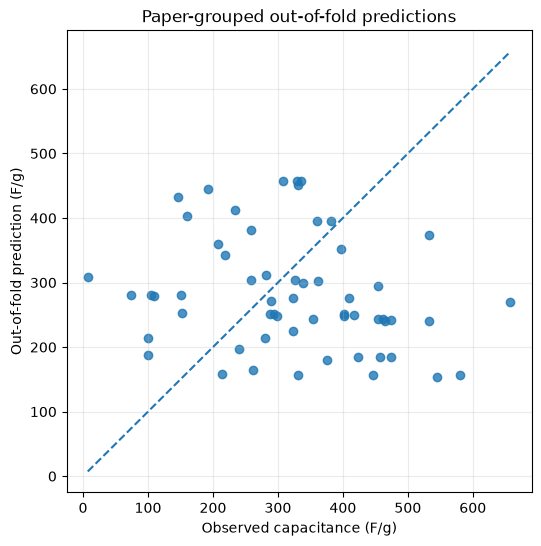

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(selected_oof["observed"], selected_oof["predicted"], alpha=0.8)
lower = min(selected_oof["observed"].min(), selected_oof["predicted"].min())
upper = max(selected_oof["observed"].max(), selected_oof["predicted"].max())
ax.plot([lower, upper], [lower, upper], linestyle="--")
ax.set_xlabel(f"Observed capacitance ({selected_unit})")
ax.set_ylabel(f"Out-of-fold prediction ({selected_unit})")
ax.set_title("Paper-grouped out-of-fold predictions")
ax.grid(alpha=0.25)
plt.show()

### 7.2 Residual distribution

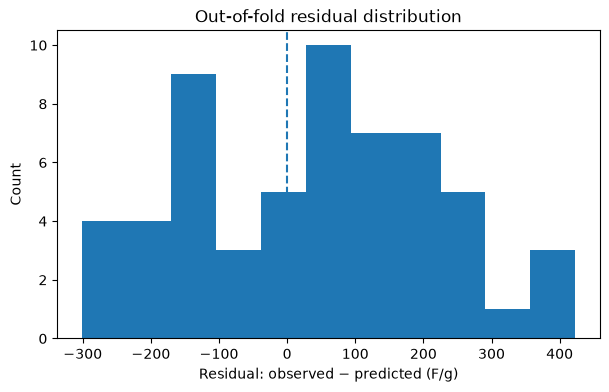

In [15]:
residuals = selected_oof["observed"] - selected_oof["predicted"]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(residuals, bins=min(12, max(5, len(residuals) // 5)))
ax.axvline(0, linestyle="--")
ax.set_xlabel(f"Residual: observed − predicted ({selected_unit})")
ax.set_ylabel("Count")
ax.set_title("Out-of-fold residual distribution")
plt.show()

## 8. Fit final models and inspect feature importance

Cross-validation is used for performance assessment. Only afterward is each final pipeline fitted on all available rows. Feature importance is model-specific, not causal evidence, and is unreliable when cross-paper performance is weak.

In [16]:
def fitted_feature_importance(fitted_pipeline: Pipeline, top_n: int = 25) -> pd.DataFrame:
    preprocessor = fitted_pipeline.named_steps["preprocessor"]
    model = fitted_pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    importance = model.feature_importances_
    return (
        pd.DataFrame({"transformed_feature": feature_names, "importance": importance})
        .sort_values("importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


final_models: dict[str, Pipeline] = {}
importance_tables: dict[str, pd.DataFrame] = {}

for target, (X, y, groups) in model_inputs.items():
    final_pipeline = build_pipeline(X)
    final_pipeline.fit(X, y)
    final_models[target] = final_pipeline
    importance_tables[target] = fitted_feature_importance(final_pipeline)

print(f"Top transformed features for {SELECTED_TARGET}:")
display(importance_tables[SELECTED_TARGET])

C:\Users\Tomal\AppData\Local\Temp\ipykernel_29908\3300696480.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
C:\Users\Tomal\AppData\Local\Temp\ipykernel_29908\3300696480.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://

Top transformed features for gravimetric_capacitance_F_g:


C:\Users\Tomal\AppData\Local\Temp\ipykernel_29908\3300696480.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()


,transformed_feature,importance
0,numeric__mass_loading_mg_cm2,0.097798
1,categorical__measurement_mode_CV,0.084600
2,categorical__measurement_mode_unknown,0.082220
3,numeric__contains_carbon_additive,0.054482
4,numeric__electrode_thickness_um,0.049350
5,numeric__missingindicator_scan_rate_mV_s,0.047390
6,numeric__vacuum_filtration,0.043861
7,numeric__missingindicator_mass_loading_mg_cm2,0.041235
8,categorical__layer_category_delaminated,0.040413
9,numeric__scan_rate_mV_s,0.036419


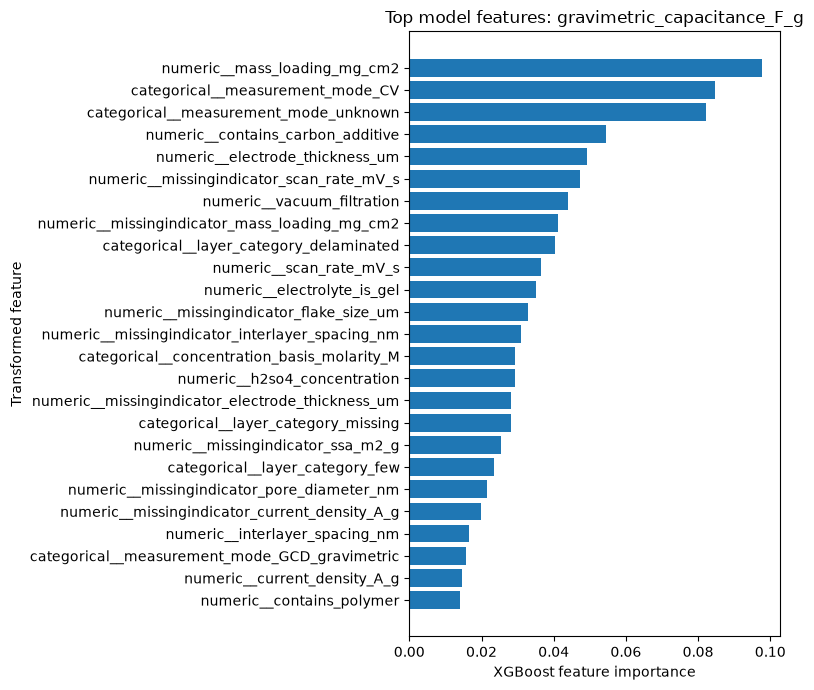

In [17]:
importance_plot = importance_tables[SELECTED_TARGET].sort_values("importance")
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(importance_plot["transformed_feature"], importance_plot["importance"])
ax.set_xlabel("XGBoost feature importance")
ax.set_ylabel("Transformed feature")
ax.set_title(f"Top model features: {SELECTED_TARGET}")
plt.tight_layout()
plt.show()

## 9. Save normalized data, metrics, predictions, and models

In [18]:
normalized_path = OUTPUT_DIR / "h2so4_corpus_normalized.csv"
metrics_path = OUTPUT_DIR / "all_target_metrics.csv"
normalized_df.to_csv(normalized_path, index=False)
metrics_table.to_csv(metrics_path, index=False)

saved_files = [normalized_path, metrics_path]
for target, pipeline in final_models.items():
    model_path = OUTPUT_DIR / f"{target}_xgboost.joblib"
    oof_path = OUTPUT_DIR / f"{target}_oof_predictions.csv"
    json_path = OUTPUT_DIR / f"{target}_metrics.json"

    joblib.dump(
        {
            "pipeline": pipeline,
            "raw_feature_columns": model_inputs[target][0].columns.tolist(),
            "target": target,
            "target_unit": TARGET_UNITS[target],
        },
        model_path,
    )
    all_oof[target].to_csv(oof_path, index=True, index_label="original_row")
    json_path.write_text(json.dumps(all_metrics[target], indent=2), encoding="utf-8")
    saved_files.extend([model_path, oof_path, json_path])

print("Saved files:")
for path in saved_files:
    print(" -", path.resolve())

Saved files:
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\h2so4_corpus_normalized.csv
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\all_target_metrics.csv
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\gravimetric_capacitance_F_g_xgboost.joblib
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\gravimetric_capacitance_F_g_oof_predictions.csv
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\gravimetric_capacitance_F_g_metrics.json
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\volumetric_capacitance_F_cm3_xgboost.joblib
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\volumetric_capacitance_F_cm3_oof_predictions.csv
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\volumetric_capacitance_F_cm3_metrics.json
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\areal_capacitance_mF_cm2_xgboost.joblib
 - C:\Users\Tomal\Desktop\mxene-geometry\xgb_notebook_outputs\areal_cap

## 10. Interpretation and next steps

- A negative R² means the model generalizes worse than a constant baseline on unseen papers.
- Compare XGBoost MAE with the median-baseline MAE. If XGBoost does not beat it, descriptor rankings should be treated as unstable.
- The areal subset is especially small and cannot support strong conclusions.
- Capacitance depends strongly on measurement conditions; missing scan rate or current density creates unobserved experimental heterogeneity.
- The most valuable data improvements are consistent measurement-condition extraction and better coverage of interlayer spacing, thickness, mass loading, SSA, pore structure, and composition.

For a publication-oriented study, compare XGBoost against simple regularized baselines and test ranking stability across repeated grouped folds or bootstrap resamples before using SHAP for scientific interpretation.